# Part 1


In [ ]:
import json
import os
import subprocess
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from train import build_modular_dataset

In [ ]:
ROOT = Path.cwd()
PART1_DIR = ROOT / "out" / "submission" / "part1"
PLOTS_DIR = PART1_DIR / "plots"
TABLES_DIR = PART1_DIR / "tables"

PART1_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

print("root:", ROOT)
print("part1:", PART1_DIR)

root: /Users/shobhit/Documents/UW/CSE 493/cse493s-spring26-hw1
part1: /Users/shobhit/Documents/UW/CSE 493/cse493s-spring26-hw1/out/submission/part1


In [ ]:
FAST_DEBUG = False

WARMUP_STEPS = 1500 if FAST_DEBUG else 100000
GROKKING_STEPS = 3000 if FAST_DEBUG else 100000
ABLATION_STEPS = 3000 if FAST_DEBUG else 100000

EVAL_INTERVAL = 100 if FAST_DEBUG else 500
LOG_INTERVAL = 100 if FAST_DEBUG else 500

BASE_OPTIMIZER = "adam"

WARMUP_WEIGHT_DECAY = 0.01
WARMUP_LR = 1e-3
WARMUP_MIN_LR = 1e-4
WARMUP_LR_SCHEDULE = "cosine"
WARMUP_WARMUP_STEPS = 1000 if not FAST_DEBUG else 50
WARMUP_GRAD_CLIP = 1.0

USE_EARLY_STOP = False

GROKKING_WEIGHT_DECAY = 0.01
EARLY_STOP_METRIC = "val_acc"
EARLY_STOP_MODE = "max"
EARLY_STOP_THRESHOLD = 0.99
EARLY_STOP_PATIENCE = 20
EARLY_STOP_MIN_STEPS = 2000 if not FAST_DEBUG else 200
EARLY_STOP_MIN_DELTA = 1e-4

print("FAST_DEBUG:", FAST_DEBUG)
print("WARMUP_STEPS:", WARMUP_STEPS)
print("BASE_OPTIMIZER:", BASE_OPTIMIZER)
print("WARMUP_LR_SCHEDULE:", WARMUP_LR_SCHEDULE)
print("USE_EARLY_STOP:", USE_EARLY_STOP)


FAST_DEBUG: False
WARMUP_STEPS: 100000
BASE_OPTIMIZER: adam
WARMUP_LR_SCHEDULE: cosine
USE_EARLY_STOP: False


In [11]:
def run(cmd: str):
    print(f"\n$ {cmd}")
    result = subprocess.run(cmd, shell=True)
    if result.returncode != 0:
        raise RuntimeError(f"Command failed with code {result.returncode}: {cmd}")


def load_history(run_dir: Path) -> pd.DataFrame:
    path = run_dir / "history.csv"
    if not path.exists():
        raise FileNotFoundError(path)
    return pd.read_csv(path)


def load_metrics(run_dir: Path) -> dict:
    path = run_dir / "metrics.json"
    if not path.exists():
        raise FileNotFoundError(path)
    with open(path, "r") as f:
        return json.load(f)


## 1.1 Data Generation

In [ ]:
rows = []
sample_rows = []

for p in [97, 113]:
    for op in ["+", "-", "/"]:
        split_dir = PART1_DIR / "splits" / f"p{p}_{'div' if op=='/' else ('add' if op=='+' else 'sub')}"
        tokenizer, train_data, val_data, test_data = build_modular_dataset(
            p=p,
            op=op,
            train_frac=0.3,
            val_frac=0.1,
            seed=42,
            save_split_dir=str(split_dir),
        )

        total = len(train_data) + len(val_data) + len(test_data)
        expected = p * (p - 1) if op == "/" else p * p

        rows.append(
            {
                "p": p,
                "op": op,
                "train": len(train_data),
                "val": len(val_data),
                "test": len(test_data),
                "total": total,
                "expected_total": expected,
                "matches_expected": total == expected,
            }
        )

        for split_name, split_data in [("train", train_data), ("val", val_data), ("test", test_data)]:
            s = split_data[0]
            full_ids = [s["x"][0]] + s["y"]
            sample_rows.append(
                {
                    "p": p,
                    "op": op,
                    "split": split_name,
                    "tokens": tokenizer.decode_ids(full_ids),
                    "target_pos": s["target_pos"],
                    "loss_mask": s["loss_mask"],
                }
            )

counts_df = pd.DataFrame(rows).sort_values(["p", "op"]).reset_index(drop=True)
samples_df = pd.DataFrame(sample_rows)

counts_df.to_csv(TABLES_DIR / "1_1_split_counts.csv", index=False)
samples_df.to_json(TABLES_DIR / "1_1_samples.json", orient="records", indent=2)

counts_df

,p,op,train,val,test,total,expected_total,matches_expected
0,97,+,2822,940,5647,9409,9409,True
1,97,-,2822,940,5647,9409,9409,True
2,97,/,2793,931,5588,9312,9312,True
3,113,+,3830,1276,7663,12769,12769,True
4,113,-,3830,1276,7663,12769,12769,True
5,113,/,3796,1265,7595,12656,12656,True


In [13]:
samples_df.head(18)

,p,op,split,tokens,target_pos,loss_mask
0,97,+,train,"[<BOS>, 73, +, 93, =, 69, <EOS>]",4,"[0.0, 0.0, 0.0, 0.0, 1.0, 0.0]"
1,97,+,val,"[<BOS>, 10, +, 14, =, 24, <EOS>]",4,"[0.0, 0.0, 0.0, 0.0, 1.0, 0.0]"
2,97,+,test,"[<BOS>, 16, +, 2, =, 18, <EOS>]",4,"[0.0, 0.0, 0.0, 0.0, 1.0, 0.0]"
3,97,-,train,"[<BOS>, 73, -, 93, =, 77, <EOS>]",4,"[0.0, 0.0, 0.0, 0.0, 1.0, 0.0]"
4,97,-,val,"[<BOS>, 10, -, 14, =, 93, <EOS>]",4,"[0.0, 0.0, 0.0, 0.0, 1.0, 0.0]"
5,97,-,test,"[<BOS>, 16, -, 2, =, 14, <EOS>]",4,"[0.0, 0.0, 0.0, 0.0, 1.0, 0.0]"
6,97,/,train,"[<BOS>, 24, /, 60, =, 78, <EOS>]",4,"[0.0, 0.0, 0.0, 0.0, 1.0, 0.0]"
7,97,/,val,"[<BOS>, 13, /, 2, =, 55, <EOS>]",4,"[0.0, 0.0, 0.0, 0.0, 1.0, 0.0]"
8,97,/,test,"[<BOS>, 77, /, 13, =, 88, <EOS>]",4,"[0.0, 0.0, 0.0, 0.0, 1.0, 0.0]"
9,113,+,train,"[<BOS>, 71, +, 4, =, 75, <EOS>]",4,"[0.0, 0.0, 0.0, 0.0, 1.0, 0.0]"


### 1.1 Write-Up

We generated modular equation datasets in the form `<BOS> a op b = c <EOS>` for `op in {+, -, /}` and `p in {97, 113}`.
For division, we excluded `b=0`, so division has fewer examples than addition/subtraction.

Key dataset sizes (train/val/test):
- `p=97, +`: `2822 / 940 / 5647` (total `9409 = 97*97`)
- `p=97, -`: `2822 / 940 / 5647` (total `9409 = 97*97`)
- `p=97, /`: `2793 / 931 / 5588` (total `9312 = 97*96`)
- `p=113, +`: `3830 / 1276 / 7663` (total `12769 = 113*113`)
- `p=113, -`: `3830 / 1276 / 7663` (total `12769 = 113*113`)
- `p=113, /`: `3796 / 1265 / 7595` (total `12656 = 113*112`)

All totals match expected counts (see `tables/1_1_split_counts.csv`), so data generation and split construction are correct.


## 1.2 Warmup: Addition/Subtraction Runs + Random Restarts

In [ ]:
import json
import shlex
import sys

SKIP_EXISTING_RUNS = True

def _latest_logged_step(run_dir: Path):
    history_path = run_dir / "history.json"

    if not history_path.exists():
        return None
    try:
        hist = json.loads(history_path.read_text())
    except Exception:
        return None
    if not hist:
        return None
    
    return hist[-1].get("step")

def _is_completed_run(run_dir: Path, target_steps: int):
    metrics_path = run_dir / "metrics.json"

    if not metrics_path.exists():
        return False

    metrics = {}
    try:
        metrics = json.loads(metrics_path.read_text())
    except Exception:
        pass

    if metrics.get("early_stop") and (run_dir / "model.pt").exists():
        return True

    latest = _latest_logged_step(run_dir)

    if isinstance(latest, int) and latest >= target_steps and (run_dir / "model.pt").exists():
        return True

    return False

def run_train(run_dir: Path, op: str, p: int, n_layer: int, seed: int, steps: int,
    weight_decay: float = WARMUP_WEIGHT_DECAY, early_stop: bool = USE_EARLY_STOP,
    optimizer: str = BASE_OPTIMIZER, lr: float = WARMUP_LR, min_lr: float = WARMUP_MIN_LR,
    lr_schedule: str = WARMUP_LR_SCHEDULE, warmup_steps: int = WARMUP_WARMUP_STEPS,
    grad_clip: float = WARMUP_GRAD_CLIP, skip_existing: bool = SKIP_EXISTING_RUNS,
):
    if skip_existing and _is_completed_run(run_dir, steps):
        print(f"[skip] already complete: {run_dir}")
        return False

    out_dir_q = shlex.quote(str(run_dir))
    early_flags = ""
    if early_stop:
        early_flags = (
            f" --early_stop"
            f" --early_stop_metric {EARLY_STOP_METRIC}"
            f" --early_stop_mode {EARLY_STOP_MODE}"
            f" --early_stop_threshold {EARLY_STOP_THRESHOLD}"
            f" --early_stop_patience {EARLY_STOP_PATIENCE}"
            f" --early_stop_min_steps {EARLY_STOP_MIN_STEPS}"
            f" --early_stop_min_delta {EARLY_STOP_MIN_DELTA}"
        )

    cmd = (
        f"{shlex.quote(sys.executable)} train.py "
        f"--mode modular --op {op} --p {p} "
        f"--n_layer {n_layer} --n_head 4 --n_embd 128 "
        f"--steps {steps} --seed {seed} "
        f"--batch_size 128 --lr {lr} --min_lr {min_lr} --lr_schedule {lr_schedule} "
        f"--warmup_steps {warmup_steps} --grad_clip {grad_clip} "
        f"--beta1 0.9 --beta2 0.95 --weight_decay {weight_decay} --optimizer {optimizer} "
        f"--eval_interval {EVAL_INTERVAL} --log_interval {LOG_INTERVAL} "
        f"--out_dir {out_dir_q} --bias"
        f"{early_flags}"
    )
    run(cmd)
    return True


warmup_runs = []
executed_warmup = 0
for op in ["+", "-"]:
    op_name = "add" if op == "+" else "sub"
    for p in [97, 113]:
        for n_layer in [1, 2]:
            run_dir = PART1_DIR / "warmup" / f"{op_name}_p{p}_l{n_layer}_s42"
            warmup_runs.append({
                "name": run_dir.name,
                "run_dir": run_dir,
                "op": op,
                "p": p,
                "n_layer": n_layer,
                "seed": 42,
            })
            executed_warmup += int(run_train( run_dir=run_dir, op=op, p=p, n_layer=n_layer, seed=42,
                steps=WARMUP_STEPS, weight_decay=WARMUP_WEIGHT_DECAY, early_stop=USE_EARLY_STOP,
                optimizer=BASE_OPTIMIZER, lr=WARMUP_LR, min_lr=WARMUP_MIN_LR, lr_schedule=WARMUP_LR_SCHEDULE,
                warmup_steps=WARMUP_WARMUP_STEPS, grad_clip=WARMUP_GRAD_CLIP,
            ))

# Required 3 random restarts for (+, p=97, 1-layer)
restart_runs = []
executed_restarts = 0
for seed in [101, 202, 303]:
    run_dir = PART1_DIR / "warmup_restarts" / f"add_p97_l1_s{seed}"
    restart_runs.append({
        "name": run_dir.name,
        "run_dir": run_dir,
        "op": "+",
        "p": 97,
        "n_layer": 1,
        "seed": seed,
    })
    executed_restarts += int(run_train( run_dir=run_dir, op="+", p=97, n_layer=1, seed=seed, steps=WARMUP_STEPS,
        weight_decay=WARMUP_WEIGHT_DECAY, early_stop=USE_EARLY_STOP, optimizer=BASE_OPTIMIZER, lr=WARMUP_LR,
        min_lr=WARMUP_MIN_LR, lr_schedule=WARMUP_LR_SCHEDULE, warmup_steps=WARMUP_WARMUP_STEPS,
        grad_clip=WARMUP_GRAD_CLIP,
    ))

print("warmup runs configured:", len(warmup_runs), "executed now:", executed_warmup)
print("restart runs configured:", len(restart_runs), "executed now:", executed_restarts)


[skip] already complete: /Users/shobhit/Documents/UW/CSE 493/cse493s-spring26-hw1/out/submission/part1/warmup/add_p97_l1_s42
[skip] already complete: /Users/shobhit/Documents/UW/CSE 493/cse493s-spring26-hw1/out/submission/part1/warmup/add_p97_l2_s42
[skip] already complete: /Users/shobhit/Documents/UW/CSE 493/cse493s-spring26-hw1/out/submission/part1/warmup/add_p113_l1_s42
[skip] already complete: /Users/shobhit/Documents/UW/CSE 493/cse493s-spring26-hw1/out/submission/part1/warmup/add_p113_l2_s42
[skip] already complete: /Users/shobhit/Documents/UW/CSE 493/cse493s-spring26-hw1/out/submission/part1/warmup/sub_p97_l1_s42
[skip] already complete: /Users/shobhit/Documents/UW/CSE 493/cse493s-spring26-hw1/out/submission/part1/warmup/sub_p97_l2_s42
[skip] already complete: /Users/shobhit/Documents/UW/CSE 493/cse493s-spring26-hw1/out/submission/part1/warmup/sub_p113_l1_s42
[skip] already complete: /Users/shobhit/Documents/UW/CSE 493/cse493s-spring26-hw1/out/submission/part1/warmup/sub_p113_l2_

In [15]:
summary_rows = []
for r in warmup_runs + restart_runs:
    m = load_metrics(r["run_dir"])
    summary_rows.append({
        "name": r["name"],
        "op": r["op"],
        "p": r["p"],
        "n_layer": r["n_layer"],
        "seed": r["seed"],
        "best_step": m.get("step"),
        "train_loss": m.get("train_loss"),
        "train_acc": m.get("train_acc"),
        "val_loss": m.get("val_loss"),
        "val_acc": m.get("val_acc"),
        "test_loss": m.get("test_loss"),
        "test_acc": m.get("test_acc"),
    })

warmup_summary_df = pd.DataFrame(summary_rows)
warmup_summary_df.to_csv(TABLES_DIR / "1_2_warmup_summary.csv", index=False)
warmup_summary_df


,name,op,p,n_layer,seed,best_step,train_loss,train_acc,val_loss,val_acc,test_loss,test_acc
0,add_p97_l1_s42,+,97,1,42,99000,2.399723,0.322821,2.439975,0.252128,2.439534,0.256596
1,add_p97_l2_s42,+,97,2,42,99000,2.398702,0.337704,2.439791,0.259574,2.438381,0.266867
2,add_p113_l1_s42,+,113,1,42,100000,2.597184,0.293211,2.634124,0.237461,2.626706,0.239462
3,add_p113_l2_s42,+,113,2,42,95500,2.600063,0.290862,2.636558,0.228840,2.629944,0.240115
4,sub_p97_l1_s42,-,97,1,42,99500,2.876577,0.217931,2.915523,0.187234,2.922901,0.154595
5,sub_p97_l2_s42,-,97,2,42,100000,2.941968,0.200567,2.977167,0.167021,2.985812,0.142199
6,sub_p113_l1_s42,-,113,1,42,97500,2.687528,0.298695,2.726709,0.244514,2.716548,0.256557
7,sub_p113_l2_s42,-,113,2,42,97500,2.752590,0.271540,2.783943,0.242163,2.777107,0.228631
8,add_p97_l1_s101,+,97,1,101,99000,2.391755,0.316797,2.433973,0.260638,2.439245,0.243138
9,add_p97_l1_s202,+,97,1,202,52500,2.451418,0.326719,2.610520,0.208511,2.627379,0.187533


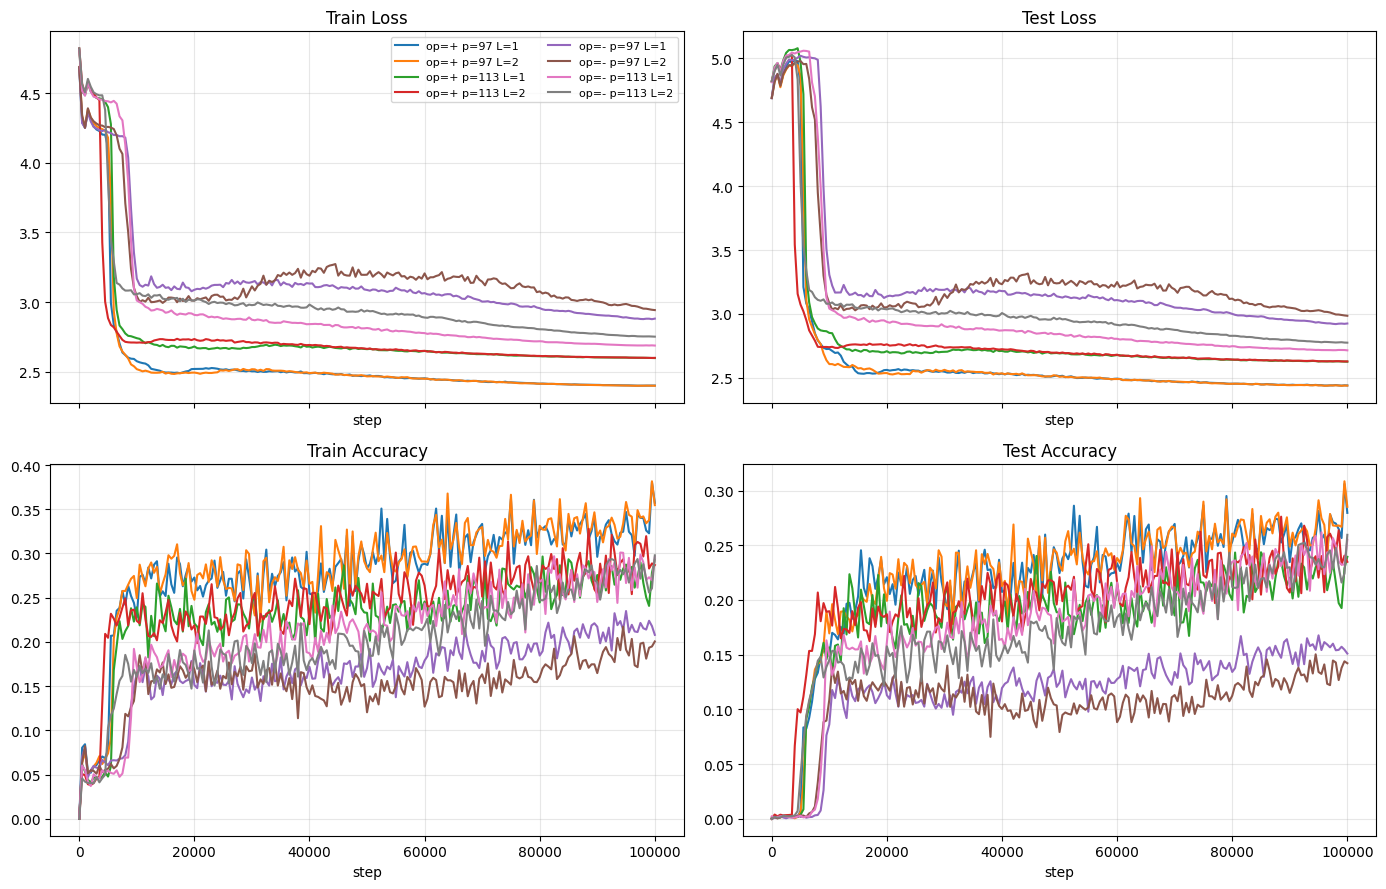

In [ ]:
# Plot warmup train/test curves for the 8 core warmup runs
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
for r in warmup_runs:
    h = load_history(r["run_dir"])
    label = f"op={r['op']} p={r['p']} L={r['n_layer']}"
    axes[0, 0].plot(h["step"], h["train_loss"], label=label)
    axes[0, 1].plot(h["step"], h["test_loss"], label=label)
    axes[1, 0].plot(h["step"], h["train_acc"], label=label)
    axes[1, 1].plot(h["step"], h["test_acc"], label=label)

axes[0, 0].set_title("Train Loss")
axes[0, 1].set_title("Test Loss")
axes[1, 0].set_title("Train Accuracy")
axes[1, 1].set_title("Test Accuracy")
for ax in axes.ravel():
    ax.set_xlabel("step")
    ax.grid(alpha=0.3)

axes[0, 0].legend(fontsize=8, ncol=2)
fig.tight_layout()
fig.savefig(PLOTS_DIR / "1_2_warmup_curves.png", dpi=180)
plt.show()


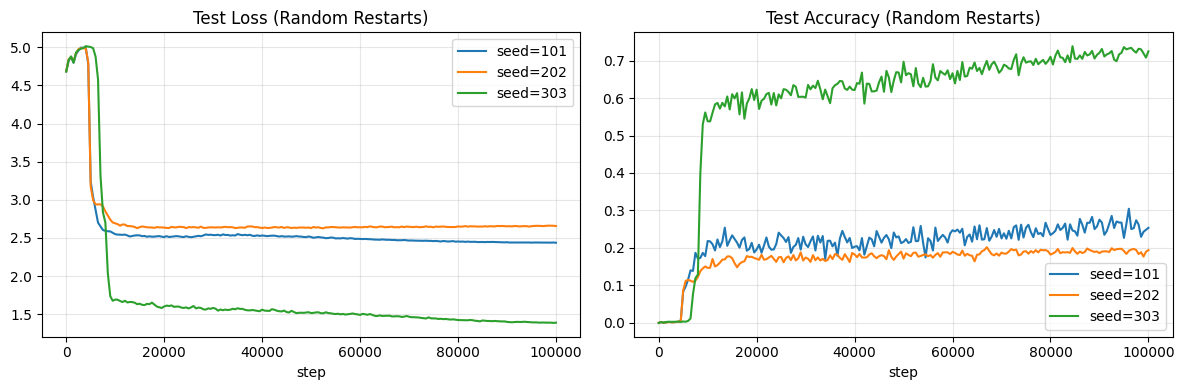

In [ ]:
# Plot random restart variability for (+, p=97, 1-layer)
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)
for r in restart_runs:
    h = load_history(r["run_dir"])
    label = f"seed={r['seed']}"
    axes[0].plot(h["step"], h["test_loss"], label=label)
    axes[1].plot(h["step"], h["test_acc"], label=label)

axes[0].set_title("Test Loss (Random Restarts)")
axes[1].set_title("Test Accuracy (Random Restarts)")
for ax in axes:
    ax.set_xlabel("step")
    ax.grid(alpha=0.3)
    ax.legend()
fig.tight_layout()
fig.savefig(PLOTS_DIR / "1_2_random_restarts.png", dpi=180)
plt.show()


### 1.2 Write-Up

Setup used for warmup experiments:
- Model configs: 1-layer and 2-layer transformers, `n_embd=128`, `n_head=4`, FFN dimension `4*128=512`
- Tasks: modular addition and subtraction
- Moduli: `p=97` and `p=113`
- Optimizer: Adam, up to `100,000` steps, answer-token-only loss masking

Main observations:
- Addition generally outperformed subtraction:
  - `add_p97_l2_s42` test accuracy `0.2669` vs `sub_p97_l2_s42` `0.1422`.
- Increasing depth from 1 to 2 layers gave small gains for addition:
  - `p=97`: `0.2566 -> 0.2669`
  - `p=113`: `0.2395 -> 0.2401`
- Subtraction behavior was less consistent especially for `p=97` where both 1-layer and 2-layer remained relatively low.

Random restart analysis for `(op=+, p=97, 1-layer)` showed high variance:
- Seed 101: test accuracy `0.2431`
- Seed 202: test accuracy `0.1875`
- Seed 303: test accuracy `0.7080`

This variance is important because with the same architecture and training budget, seed choice can substantially affect generalization.


## 1.3 Grokking: Division (p=97)

In [ ]:
import json
import shlex
import sys

SKIP_EXISTING_GROKKING_RUNS = True

def _latest_logged_step(run_dir: Path):
    history_path = run_dir / "history.json"
    if not history_path.exists():
        return None
    try:
        hist = json.loads(history_path.read_text())
    except Exception:
        return None
    
    if not hist:
        return None
    
    return hist[-1].get("step")

def _is_completed_run(run_dir: Path, target_steps: int):
    metrics_path = run_dir / "metrics.json"
    if not metrics_path.exists():
        return False

    metrics = {}
    try:
        metrics = json.loads(metrics_path.read_text())
    except Exception:
        pass

    if metrics.get("early_stop") and (run_dir / "model.pt").exists():
        return True

    latest = _latest_logged_step(run_dir)
    if isinstance(latest, int) and latest >= target_steps and (run_dir / "model.pt").exists():
        return True

    return False

baseline_div_dir = PART1_DIR / "grokking" / "baseline_div_p97"
if SKIP_EXISTING_GROKKING_RUNS and _is_completed_run(baseline_div_dir, GROKKING_STEPS):
    print(f"[skip] baseline already complete: {baseline_div_dir}")
else:
    cmd = (
        f"{shlex.quote(sys.executable)} train.py "
        "--mode modular --op / --p 97 "
        "--n_layer 2 --n_head 4 --n_embd 128 "
        f"--steps {GROKKING_STEPS} --seed 42 "
        "--batch_size 128 --lr 1e-3 --min_lr 1e-4 --lr_schedule cosine --warmup_steps 1000 --grad_clip 1.0 "
        "--beta1 0.9 --beta2 0.95 "
        f"--weight_decay {GROKKING_WEIGHT_DECAY} --optimizer {BASE_OPTIMIZER} "
        f"--eval_interval {EVAL_INTERVAL} --log_interval {LOG_INTERVAL} "
        f"--out_dir {shlex.quote(str(baseline_div_dir))} --bias --resume"
    )
    run(cmd)



$ /opt/homebrew/Caskroom/miniconda/base/envs/cse493/bin/python train.py --mode modular --op / --p 97 --n_layer 2 --n_head 4 --n_embd 128 --steps 100000 --seed 42 --batch_size 128 --lr 1e-3 --min_lr 1e-4 --lr_schedule cosine --warmup_steps 1000 --grad_clip 1.0 --beta1 0.9 --beta2 0.95 --weight_decay 0.01 --optimizer adam --eval_interval 500 --log_interval 500 --out_dir '/Users/shobhit/Documents/UW/CSE 493/cse493s-spring26-hw1/out/submission/part1/grokking/baseline_div_p97' --bias --resume
number of parameters: 0.41M
[resume] model_last.pt not found in /Users/shobhit/Documents/UW/CSE 493/cse493s-spring26-hw1/out/submission/part1/grokking/baseline_div_p97; starting fresh
[resume] history found with last step=7500
device=mps train=2793 val=931 test=5588 batch_size=128
step=8000 train_loss=4.572430 train_acc=0.0132 val_loss=4.604634 val_acc=0.0107 test_loss=4.598133 test_acc=0.0088
step=8500 train_loss=4.569263 train_acc=0.0129 val_loss=4.595882 val_acc=0.0140 test_loss=4.596638 test_acc=0

,run,train_acc_1_step,test_acc_1_step,grokking_delay_steps
0,baseline_div_p97,None,None,None


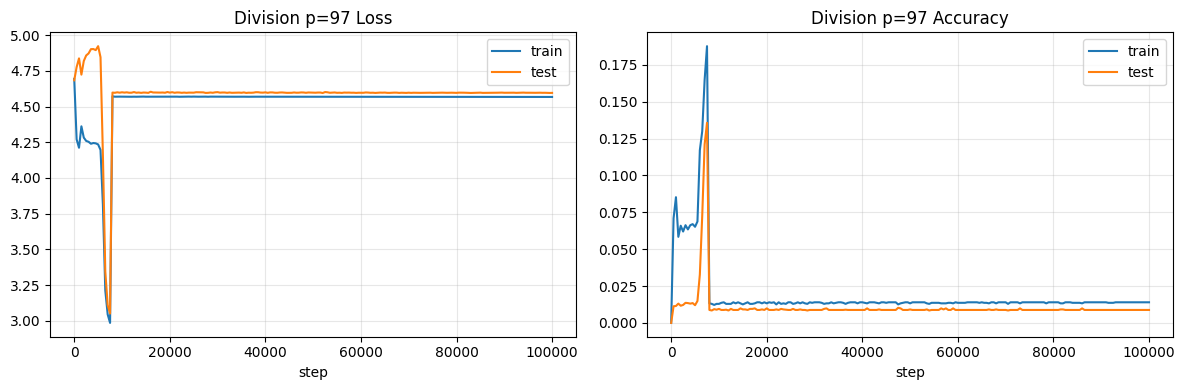

In [ ]:
h = load_history(baseline_div_dir)

train_one = h.loc[h["train_acc"] >= 1.0, "step"]
train_one_step = int(train_one.iloc[0]) if not train_one.empty else None

if train_one_step is None:
    test_one_step = None
    grokking_delay = None
else:
    after = h[h["step"] >= train_one_step]
    test_one = after.loc[after["test_acc"] >= 1.0, "step"]
    test_one_step = int(test_one.iloc[0]) if not test_one.empty else None
    grokking_delay = (test_one_step - train_one_step) if test_one_step is not None else None

grokking_summary = pd.DataFrame([
    {
        "run": "baseline_div_p97",
        "train_acc_1_step": train_one_step,
        "test_acc_1_step": test_one_step,
        "grokking_delay_steps": grokking_delay,
    }
])
grokking_summary.to_csv(TABLES_DIR / "1_3_grokking_summary.csv", index=False)
display(grokking_summary)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)
axes[0].plot(h["step"], h["train_loss"], label="train")
axes[0].plot(h["step"], h["test_loss"], label="test")
axes[0].set_title("Division p=97 Loss")
axes[1].plot(h["step"], h["train_acc"], label="train")
axes[1].plot(h["step"], h["test_acc"], label="test")
axes[1].set_title("Division p=97 Accuracy")

if train_one_step is not None:
    axes[1].axvline(train_one_step, linestyle="--", alpha=0.7, label="train acc=1")
if test_one_step is not None:
    axes[1].axvline(test_one_step, linestyle=":", alpha=0.7, label="test acc=1")

for ax in axes:
    ax.set_xlabel("step")
    ax.grid(alpha=0.3)
    ax.legend()

fig.tight_layout()
fig.savefig(PLOTS_DIR / "1_3_grokking_baseline.png", dpi=180)
plt.show()


### 1.3 Write-Up

For the baseline grokking run (`op=/`, `p=97`, 2-layer), the model did not exhibit full grokking under the current hyperparameters.

Observed behavior:
- Best test accuracy occurred early: about `0.1356` at step `7500`.
- After this early peak, train/val/test accuracies all degraded over long training.
- Final metrics were near chance-level for `p=97` (`~1/97`):
  - final train accuracy `0.0140`
  - final test accuracy `0.0088`

Because train accuracy never reached `1.0`, the grokking-delay metric (`test_acc_1_step - train_acc_1_step`) is undefined.

In conclusion, with this baseline configuration, we were not able to reproduce a successful grokking transition and instead, we observed an early transient improvement followed by collapse.

## 1.4 Ablations

Ablation A: Increase weight decay.
Ablation B: Reduce train fraction.


In [23]:
import shlex
import sys

ablation_runs = [
    {
        "name": "abl_weight_decay_0p05",
        "weight_decay": 0.05,
        "train_frac": 0.3,
        "val_frac": 0.1,
        "lr": 1e-3,
    },
    {
        "name": "abl_trainfrac_0p2",
        "weight_decay": 0.01,
        "train_frac": 0.2,
        "val_frac": 0.1,
        "lr": 1e-3,
    },
]

executed_ablations = 0
for ab in ablation_runs:
    run_dir = PART1_DIR / "ablations" / ab["name"]
    if SKIP_EXISTING_GROKKING_RUNS and _is_completed_run(run_dir, ABLATION_STEPS):
        print(f"[skip] ablation already complete: {run_dir}")
        continue

    cmd = (
        f"{shlex.quote(sys.executable)} train.py "
        "--mode modular --op / --p 97 "
        "--n_layer 2 --n_head 4 --n_embd 128 "
        f"--steps {ABLATION_STEPS} --seed 42 "
        "--batch_size 128 "
        f"--lr {ab['lr']} --min_lr 1e-4 --lr_schedule cosine --warmup_steps 1000 --grad_clip 1.0 "
        "--beta1 0.9 --beta2 0.95 "
        f"--weight_decay {ab['weight_decay']} --optimizer {BASE_OPTIMIZER} "
        f"--train_frac {ab['train_frac']} --val_frac {ab['val_frac']} "
        f"--eval_interval {EVAL_INTERVAL} --log_interval {LOG_INTERVAL} "
        f"--out_dir {shlex.quote(str(run_dir))} --bias --resume"
    )
    run(cmd)
    executed_ablations += 1

print("ablation runs configured:", len(ablation_runs), "executed now:", executed_ablations)



$ /opt/homebrew/Caskroom/miniconda/base/envs/cse493/bin/python train.py --mode modular --op / --p 97 --n_layer 2 --n_head 4 --n_embd 128 --steps 100000 --seed 42 --batch_size 128 --lr 0.001 --min_lr 1e-4 --lr_schedule cosine --warmup_steps 1000 --grad_clip 1.0 --beta1 0.9 --beta2 0.95 --weight_decay 0.05 --optimizer adam --train_frac 0.3 --val_frac 0.1 --eval_interval 500 --log_interval 500 --out_dir '/Users/shobhit/Documents/UW/CSE 493/cse493s-spring26-hw1/out/submission/part1/ablations/abl_weight_decay_0p05' --bias --resume
number of parameters: 0.41M
[resume] loaded model from /Users/shobhit/Documents/UW/CSE 493/cse493s-spring26-hw1/out/submission/part1/ablations/abl_weight_decay_0p05/model_last.pt
[resume] loaded optimizer from /Users/shobhit/Documents/UW/CSE 493/cse493s-spring26-hw1/out/submission/part1/ablations/abl_weight_decay_0p05/optimizer_last.pt
[resume] history found with last step=74500
device=mps train=2793 val=931 test=5588 batch_size=128
step=75000 train_loss=4.529249

In [24]:
def grokking_step(history_df: pd.DataFrame):
    # Step where test error becomes 0 (test_acc=1) after train error has vanished (train_acc=1).
    train_zero_steps = history_df.loc[history_df["train_acc"] >= 1.0, "step"]
    if train_zero_steps.empty:
        return None, None, None
    first_train_zero = int(train_zero_steps.iloc[0])

    after = history_df[history_df["step"] >= first_train_zero]
    test_zero_steps = after.loc[after["test_acc"] >= 1.0, "step"]
    if test_zero_steps.empty:
        return first_train_zero, None, None

    first_test_zero = int(test_zero_steps.iloc[0])
    return first_train_zero, first_test_zero, first_test_zero - first_train_zero


rows = []
baseline_hist = load_history(baseline_div_dir)
base_train1, base_test1, base_delay = grokking_step(baseline_hist)
rows.append(
    {
        "run": "baseline_div_p97",
        "train_acc_1_step": base_train1,
        "test_acc_1_step": base_test1,
        "grokking_delay_steps": base_delay,
    }
)

for ab in ablation_runs:
    run_dir = PART1_DIR / "ablations" / ab["name"]
    h = load_history(run_dir)
    train1, test1, delay = grokking_step(h)
    rows.append(
        {
            "run": ab["name"],
            "train_acc_1_step": train1,
            "test_acc_1_step": test1,
            "grokking_delay_steps": delay,
        }
    )

ablation_df = pd.DataFrame(rows)
ablation_df.to_csv(TABLES_DIR / "1_4_ablation_comparison.csv", index=False)
display(ablation_df)


,run,train_acc_1_step,test_acc_1_step,grokking_delay_steps
0,baseline_div_p97,None,None,None
1,abl_weight_decay_0p05,None,None,None
2,abl_trainfrac_0p2,None,None,None


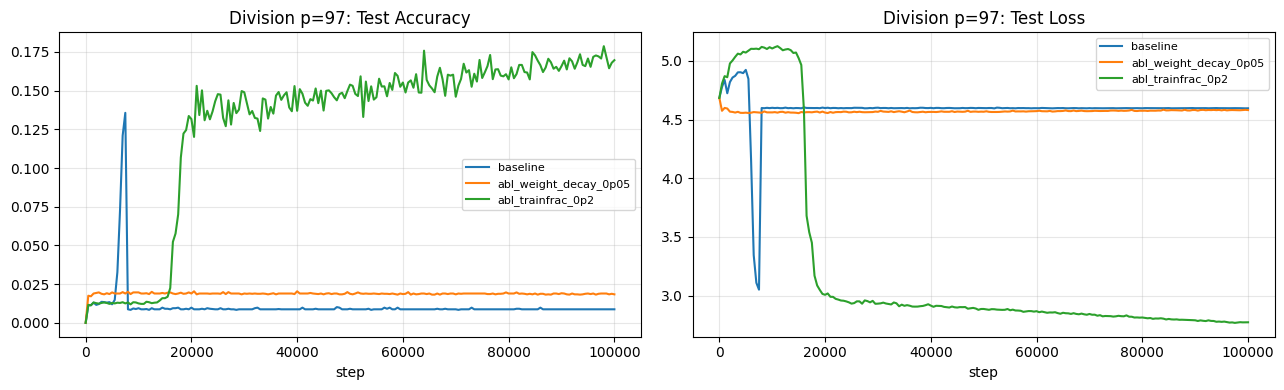

In [ ]:
# Overlay baseline + ablations on test accuracy and test loss
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharex=True)
axes[0].plot(baseline_hist["step"], baseline_hist["test_acc"], label="baseline")
axes[1].plot(baseline_hist["step"], baseline_hist["test_loss"], label="baseline")

for ab in ablation_runs:
    run_dir = PART1_DIR / "ablations" / ab["name"]
    h = load_history(run_dir)
    axes[0].plot(h["step"], h["test_acc"], label=ab["name"])
    axes[1].plot(h["step"], h["test_loss"], label=ab["name"])

axes[0].set_title("Division p=97: Test Accuracy")
axes[1].set_title("Division p=97: Test Loss")
for ax in axes:
    ax.set_xlabel("step")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

fig.tight_layout()
fig.savefig(PLOTS_DIR / "1_4_ablation_overlay.png", dpi=180)
plt.show()


### 1.4 Write-Up

We tested two ablations on the division task (`p=97`) to study whether grokking could happen faster and more reliably.

Ablation A (stronger regularization):
- Increased `weight_decay` to `0.05`
- This caused severe underfitting
- Best test accuracy of only `0.0204`

Ablation B (smaller training set):
- Reduce `train_frac` to `0.2` (kept `val_frac=0.1`)
- This improved over baseline, but still no grokking
- Best test accuracy `0.1787` (better than baseline best `0.1356`), but never reached `1.0`

Interpretation:
- Very high weight decay harmed optimization for this setup.
- Reducing training fraction changed the dynamics and gave better peak generalization than baseline, but still did not trigger full train/test-perfect grokking.
- For both ablations, `train_acc_1_step` and `test_acc_1_step` remained undefined (no perfect-accuracy regime), so grokking delay cannot be measured.


## Inference Demo for Addition


In [27]:
from pathlib import Path
import shlex
import sys

if 'warmup_runs' in globals() and warmup_runs:
    demo_ckpt = warmup_runs[0]['run_dir']
else:
    candidate = Path('out/submission/part1/warmup/add_p97_l1_s42')
    if not candidate.exists():
        raise FileNotFoundError(
            'No warmup checkpoint found. Run the warmup training cell first.'
        )
    demo_ckpt = candidate

cmd = (
    f"{shlex.quote(sys.executable)} inference.py "
    f"--checkpoint_dir {shlex.quote(str(demo_ckpt))} "
    "--task equation --a 7 --b 8 --op +"
)
run(cmd)



$ /opt/homebrew/Caskroom/miniconda/base/envs/cse493/bin/python inference.py --checkpoint_dir '/Users/shobhit/Documents/UW/CSE 493/cse493s-spring26-hw1/out/submission/part1/warmup/add_p97_l1_s42' --task equation --a 7 --b 8 --op +
device=mps
number of parameters: 0.21M
prediction: 7 + 8 = 15


## Output Checklist

Expected outputs under `out/submission/part1/`:
- `splits/` with jsonl split files + summaries
- `warmup/` and `warmup_restarts/` checkpoints/histories
- `grokking/` checkpoint/history + `tables/1_3_grokking_summary.csv`
- `ablations/` checkpoint/histories + `tables/1_4_ablation_comparison.csv`
- `plots/` generated figures
- `tables/` generated csv summaries
